# 🚀 ISO 9001 AI RAG Pipeline & Chatbot Evaluation

This notebook visualizes the evaluation results of 5 open-source Large Language Models (LLMs) and the chatbot stability tuning process within the ISO 9001:2015 Quality Management System domain.

## 🏗️ 1. Overall System Architecture & RAG Flow
This diagram intuitively illustrates the physically distributed processing environment (Mac ↔ Ubuntu Server) and the core RAG data flow.

```mermaid
%%{init: {'theme': 'base', 'themeVariables': {'primaryColor': '#ffffff', 'primaryTextColor': '#24292e', 'primaryBorderColor': '#512DA8', 'lineColor': '#512DA8', 'fontFamily': 'ui-monospace, SFMono-Regular, Consolas, monospace'}}}%%
graph TD
    subgraph Canvas [" "]
        direction TD
        
        subgraph Mac [💻 Local MacBook]
            direction TD
            User((User))
            PDF[📄 ISO 9001 PDF]
            UI[Streamlit Chat UI]
            
            User <--> L2[2. Question & Answer] <--> UI
        end
        
        subgraph Ubuntu [🖥️ Remote Ubuntu DGX Server]
            direction TD
            API[FastAPI Server]
            DB[(Chroma DB)]
            LLM[Local LLMs: DeepSeek, Llama]
            
            %% Internal Server Flows
            API <--> L4[4. Vector Search] <--> DB
            API <--> L5[5. Inference] <--> LLM
        end
        
        %% Cross-boundary Flows
        PDF -.-> L1[1. Indexing] -.-> DB
        UI <--> L3[3. REST API] <--> API
    end

    %% Purple Pro Styles
    style Canvas fill:#ffffff,stroke:none
    
    %% MacBook: Clean white with purple dashed border
    style Mac fill:#ffffff,stroke:#9575CD,stroke-width:2px,stroke-dasharray: 5 5,color:#24292e
    
    %% DGX Server: Very light purple background
    style Ubuntu fill:#F3E5F5,stroke:#512DA8,stroke-width:3px,color:#24292e
    
    %% Elements: Purple shades
    style UI fill:#ffffff,stroke:#9575CD,stroke-width:2px,color:#24292e
    style PDF fill:#ffffff,stroke:#9575CD,stroke-width:2px,color:#24292e
    style User fill:#ffffff,stroke:#9575CD,stroke-width:2px,color:#24292e
    
    style API fill:#E1BEE7,stroke:#512DA8,stroke-width:2px,color:#24292e
    style DB fill:#E1BEE7,stroke:#512DA8,stroke-width:2px,color:#24292e
    style LLM fill:#CE93D8,stroke:#512DA8,stroke-width:2px,color:#24292e
    
    %% Explicit label nodes to prevent dark mode black boxes
    style L1 fill:#ffffff,stroke:#D1C4E9,stroke-width:1px,color:#586069
    style L2 fill:#ffffff,stroke:#D1C4E9,stroke-width:1px,color:#586069
    style L3 fill:#ffffff,stroke:#D1C4E9,stroke-width:1px,color:#586069
    style L4 fill:#ffffff,stroke:#D1C4E9,stroke-width:1px,color:#586069
    style L5 fill:#ffffff,stroke:#D1C4E9,stroke-width:1px,color:#586069
```


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('default')
sns.set_theme(style="whitegrid", rc={'axes.facecolor': 'white', 'figure.facecolor': 'white'})

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['savefig.transparent'] = False
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['text.color'] = '#24292e'
plt.rcParams['axes.labelcolor'] = '#24292e'
plt.rcParams['xtick.color'] = '#586069'
plt.rcParams['ytick.color'] = '#586069'

purple_palette = ['#E1BEE7', '#CE93D8', '#BA68C8', '#AB47BC', '#9C27B0']
light_purple = '#D1C4E9'
mid_purple = '#9575CD'
dark_purple = '#512DA8'

def draw_purple_table(df, title):
    fig, ax = plt.subplots(figsize=(10, len(df)*0.5 + 1), facecolor='white')
    ax.axis('off')
    table = ax.table(cellText=df.values, colLabels=df.columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(light_purple)
            cell.set_text_props(weight='bold', color=dark_purple, fontsize=13)
        else:
            cell.set_facecolor('#ffffff' if row % 2 == 0 else '#F8F4FA')
            cell.set_text_props(color='#24292e')
        cell.set_edgecolor('#D1C4E9')
    plt.title(title, fontsize=16, pad=20, color=dark_purple, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 📊 2. RAG Performance Metrics

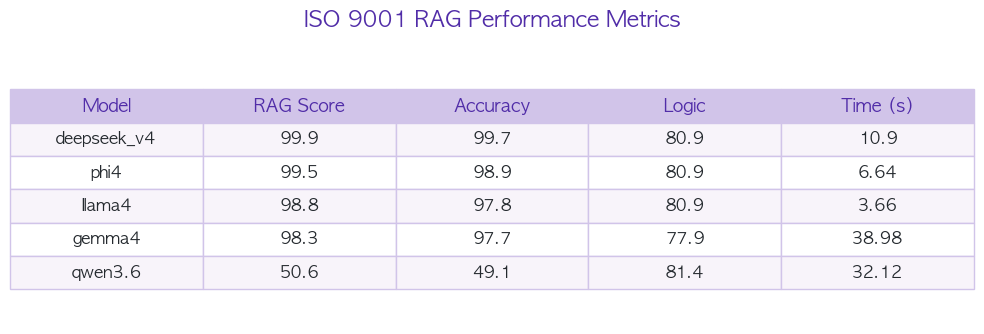

In [2]:
data = {
    'Model': ['deepseek_v4', 'phi4', 'llama4', 'gemma4', 'qwen3.6'],
    'RAG Score': [99.9, 99.5, 98.8, 98.3, 50.6],
    'Accuracy': [99.7, 98.9, 97.8, 97.7, 49.1],
    'Logic': [80.9, 80.9, 80.9, 77.9, 81.4],
    'Time (s)': [10.9, 6.64, 3.66, 38.98, 32.12]
}
df = pd.DataFrame(data)
df = df.sort_values(by='RAG Score', ascending=False)
draw_purple_table(df, 'ISO 9001 RAG Performance Metrics')

## 📊 3. RAG Performance Comparison (Bar Chart)

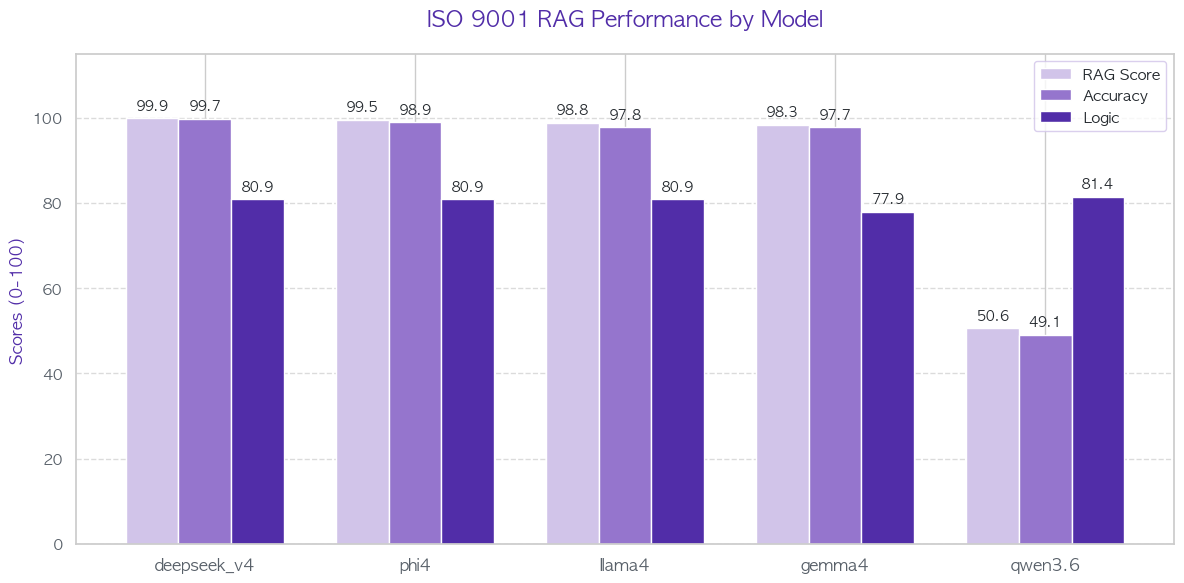

In [3]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
x = np.arange(len(df['Model']))
width = 0.25

ax.bar(x - width, df['RAG Score'], width, label='RAG Score', color=light_purple)
ax.bar(x, df['Accuracy'], width, label='Accuracy', color=mid_purple)
ax.bar(x + width, df['Logic'], width, label='Logic', color=dark_purple)

ax.set_ylabel('Scores (0-100)', fontsize=12, fontweight='bold', color=dark_purple)
ax.set_title('ISO 9001 RAG Performance by Model', fontsize=16, pad=20, color=dark_purple, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], fontsize=12, fontweight='bold')
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor=light_purple)

for i, v in enumerate(df['RAG Score']): ax.text(i - width, v + 2, str(v), ha='center', fontsize=10, color='#24292e', fontweight='bold')
for i, v in enumerate(df['Accuracy']): ax.text(i, v + 2, str(v), ha='center', fontsize=10, color='#24292e', fontweight='bold')
for i, v in enumerate(df['Logic']): ax.text(i + width, v + 2, str(v), ha='center', fontsize=10, color='#24292e', fontweight='bold')

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 115)
plt.tight_layout()
plt.show()

## ⏱️ 4. Average Inference Time per Model

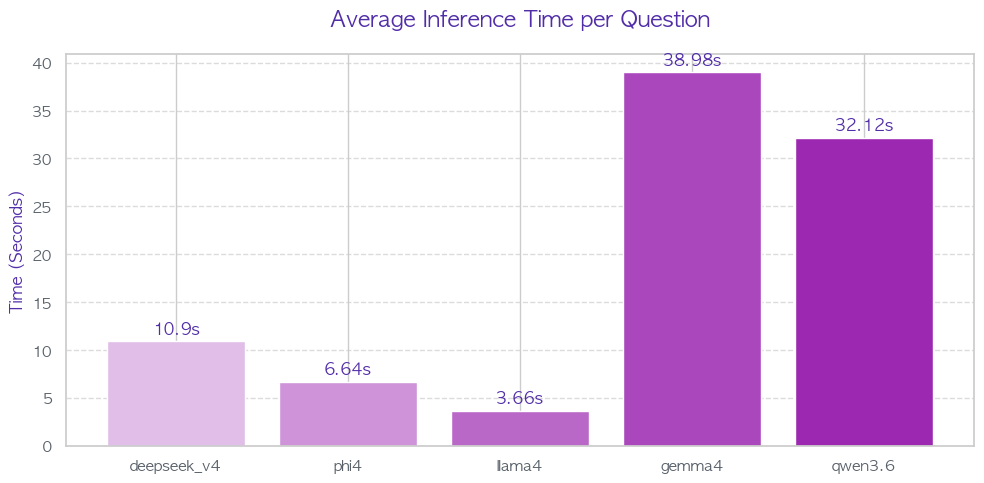

In [4]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')

bars = ax.bar(df['Model'], df['Time (s)'], color=purple_palette)
ax.set_ylabel('Time (Seconds)', fontsize=12, fontweight='bold', color=dark_purple)
ax.set_title('Average Inference Time per Question', fontsize=16, pad=20, color=dark_purple, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval}s", ha='center', va='bottom', fontsize=12, fontweight='bold', color=dark_purple)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## ⚡ 5. Inference Speed vs. RAG Performance

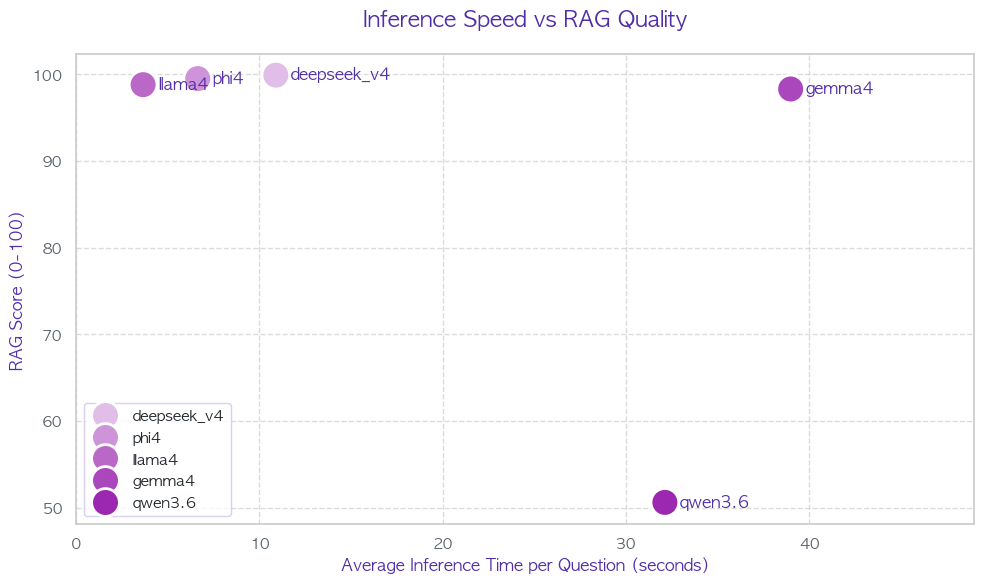

In [5]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
scatter = sns.scatterplot(data=df, x='Time (s)', y='RAG Score', 
                          s=400, hue='Model', palette=purple_palette, edgecolor='white', linewidth=2, ax=ax)

for i in range(df.shape[0]):
    ax.text(df['Time (s)'].iloc[i] + 0.8, df['RAG Score'].iloc[i] - 0.5, 
             df['Model'].iloc[i], fontsize=12, fontweight='bold', color=dark_purple)

ax.set_title('Inference Speed vs RAG Quality', fontsize=16, pad=20, color=dark_purple, fontweight='bold')
ax.set_xlabel('Average Inference Time per Question (seconds)', fontsize=12, fontweight='bold', color=dark_purple)
ax.set_ylabel('RAG Score (0-100)', fontsize=12, fontweight='bold', color=dark_purple)
ax.set_xlim(0, max(df['Time (s)']) + 10)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(frameon=True, facecolor='white', edgecolor=light_purple)

plt.tight_layout()
plt.show()

## 📉 6. DeepSeek Error Rate Reduction via Parameter Tuning

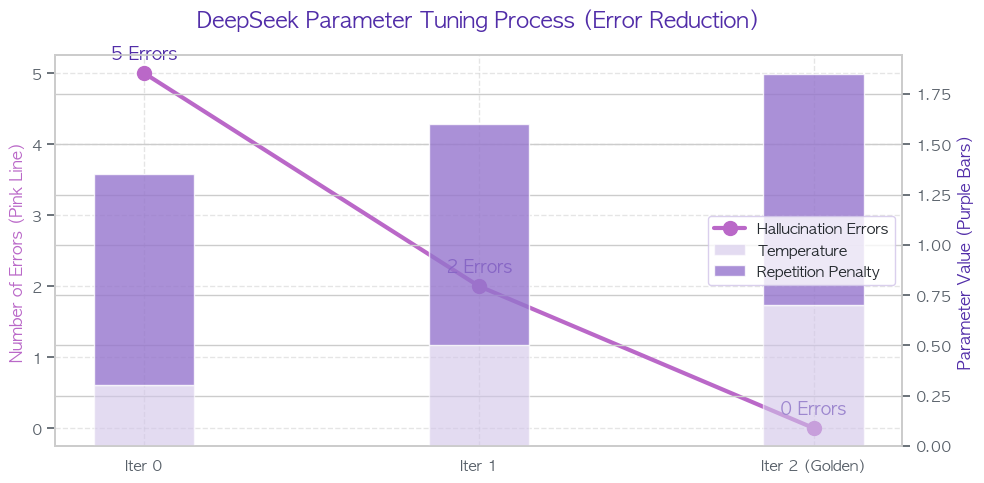

In [6]:
tuning_data = {
    'Iteration': ['Iter 0', 'Iter 1', 'Iter 2 (Golden)'],
    'Temperature': [0.3, 0.5, 0.7],
    'Rep. Penalty': [1.05, 1.1, 1.15],
    'Errors (per 100 Qs)': [5, 2, 0]
}
df_tune = pd.DataFrame(tuning_data)

fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')
ax2 = ax1.twinx()

ax1.plot(df_tune['Iteration'], df_tune['Errors (per 100 Qs)'], marker='o', color='#BA68C8', linewidth=3, markersize=10, label='Hallucination Errors')
ax2.bar(df_tune['Iteration'], df_tune['Temperature'], width=0.3, alpha=0.6, color=light_purple, label='Temperature')
ax2.bar(df_tune['Iteration'], df_tune['Rep. Penalty'], width=0.3, alpha=0.8, color=mid_purple, bottom=df_tune['Temperature'], label='Repetition Penalty')

ax1.set_ylabel('Number of Errors (Pink Line)', color='#BA68C8', fontsize=12, fontweight='bold')
ax2.set_ylabel('Parameter Value (Purple Bars)', color=dark_purple, fontsize=12, fontweight='bold')
plt.title('DeepSeek Parameter Tuning Process (Error Reduction)', fontsize=16, pad=20, color=dark_purple, fontweight='bold')
ax1.grid(True, alpha=0.5, linestyle='--')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right', frameon=True, facecolor='white', edgecolor=light_purple)

for i, v in enumerate(df_tune['Errors (per 100 Qs)']): ax1.text(i, v + 0.2, f"{v} Errors", color=dark_purple, fontweight='bold', ha='center', fontsize=13)

plt.tight_layout()
plt.show()

## 🥧 7. 100-Question Gauntlet Dataset Composition

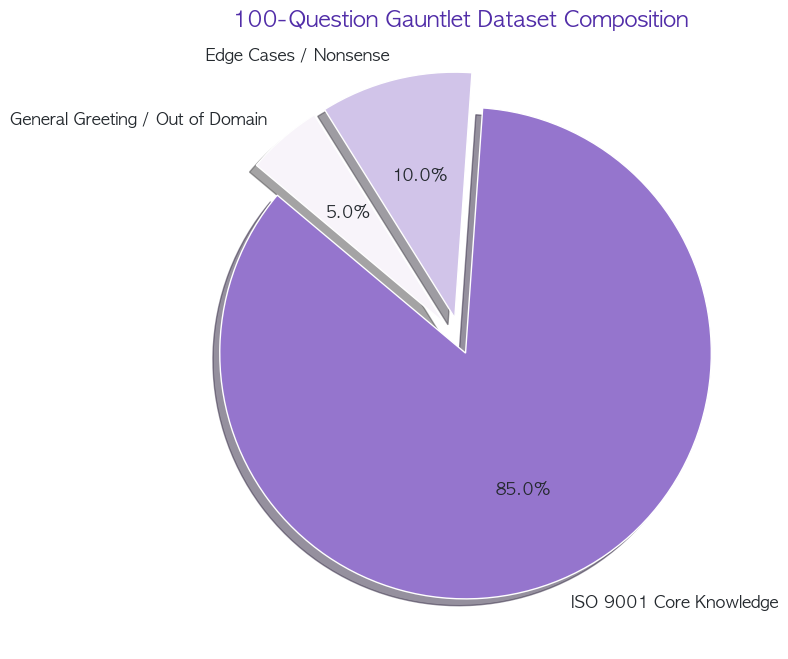

In [7]:
labels = ['ISO 9001 Core Knowledge', 'Edge Cases / Nonsense', 'General Greeting / Out of Domain']
sizes = [85, 10, 5]
colors = [mid_purple, light_purple, '#F8F4FA']
explode = (0.05, 0.1, 0.1)

fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#24292e'})
plt.title('100-Question Gauntlet Dataset Composition', fontsize=16, color=dark_purple, fontweight='bold')
plt.tight_layout()
plt.show()

## 🛡️ 8. Chatbot Stability Gauntlet Final Results

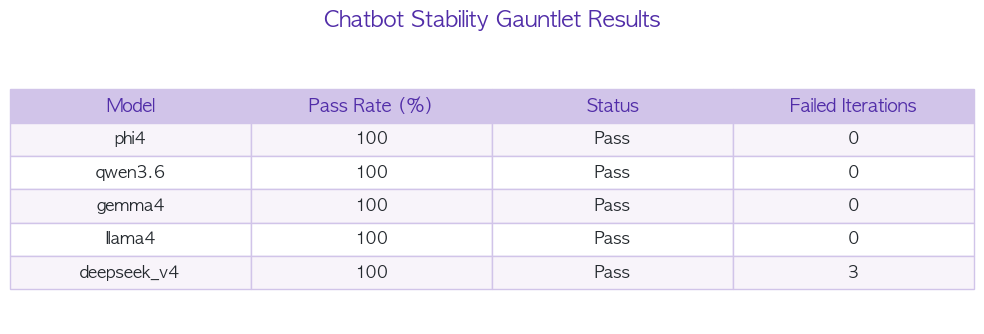

In [8]:
gauntlet_data = {
    'Model': ['phi4', 'qwen3.6', 'gemma4', 'llama4', 'deepseek_v4'],
    'Pass Rate (%)': [100, 100, 100, 100, 100],
    'Status': ['Pass', 'Pass', 'Pass', 'Pass', 'Pass'],
    'Failed Iterations': [0, 0, 0, 0, 3]
}
df_gauntlet = pd.DataFrame(gauntlet_data)

draw_purple_table(df_gauntlet, 'Chatbot Stability Gauntlet Results')